In [1]:
import phobos as kbench
import phobos
from xaosim.shmlib import shm
import numpy as np
import matplotlib.pyplot as plt
from time import sleep
import json

arch = kbench.Arch6()

def load_tt(json_path, key):
    with open(json_path) as f:
        content = json.load(f)
        f.close()
        
    return np.array(content[key])

✅ BMC lib found. Running in control mode.


In [2]:
phobos.XPOW().turn_off()

Check if current and voltage are correctly applied

In [3]:
channel = 17
current = 300 # mA
tension = 10 # V

CUR = current * 65535 / 300
VOLT = tension * 65535 / 40

In [4]:
phobos.XPOW().send_command(f"CH:{channel}-{channel}:CUR:{int(CUR)}")

'CH:17-17:CUR:65535\t>> Channel 17-17 set to 65535'

In [5]:
phobos.XPOW().send_command(f"CH:{channel}-{channel}:VOLT:{int(VOLT)}")

'CH:17-17:VOLT:16383\t>> Channel 17-17 set to 16383'

In [6]:
phobos.XPOW().send_command(f"CH:{channel}:VAL?")

'CH:17:VAL?\t>> Channel 17 = 9.987V, 13.687mA'

Cred3 camera initialized with dark subtraction


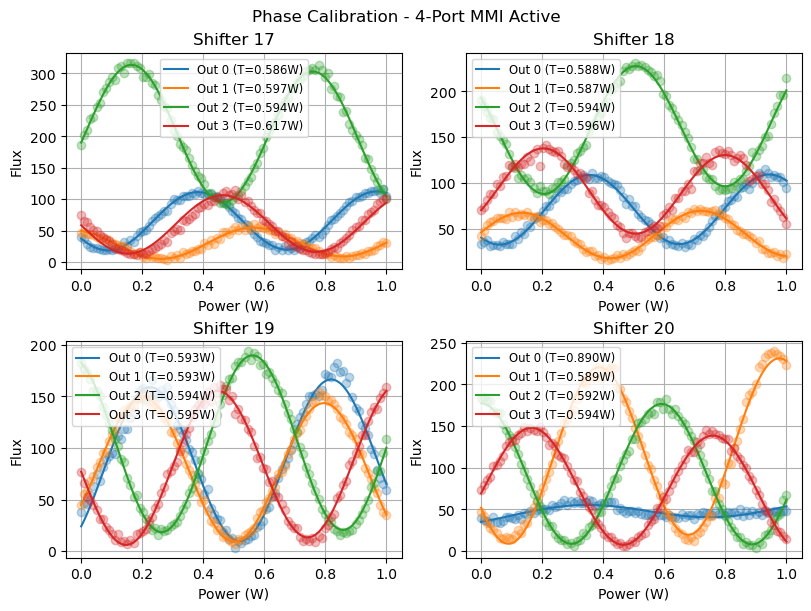

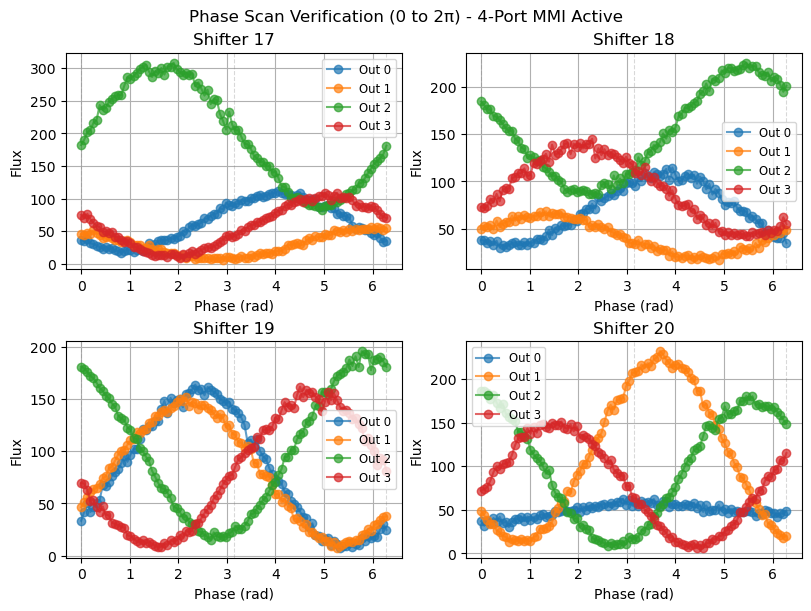

array([[[ 39.2413559 ,  46.57863235, 185.99757385,  74.68960571],
        [ 36.15135574,  47.42863464, 202.02757263,  65.73960876],
        [ 29.22135925,  45.39863205, 210.80757141,  63.82960892],
        ...,
        [109.97134399,  26.8686409 , 114.87759399,  95.37960815],
        [115.86135101,  31.62863922, 116.67759705,  99.88961029],
        [105.93135071,  30.1186409 , 100.20759583, 101.26960754]],

       [[ 33.11135864,  42.11863327, 190.24757385,  70.22960663],
        [ 35.21135712,  47.07863235, 183.74757385,  73.87960815],
        [ 36.9913559 ,  53.46864319, 177.90757751,  81.33960724],
        ...,
        [106.04135132,  22.65863991, 196.58758545,  69.51960754],
        [100.56134796,  17.76864052, 195.97758484,  63.0696106 ],
        [ 94.39134979,  21.67864037, 214.84757996,  55.19960785]],

       [[ 37.62135696,  44.62863159, 182.46757507,  76.62960815],
        [ 46.77135849,  55.16864395, 176.96757507,  66.05960846],
        [ 45.80135727,  58.42864227, 172.39758

In [7]:
phobos.Arch6().phase_calibration(plot=True)

In [13]:
phobos.XPOW().turn_off()
#[s.set_phase(2*np.pi) for s in phobos.Arch6().shifters]

🧬 Starting Genetic Calibration for Arch6...
✅ Genetic calibration complete in 44 iterations.


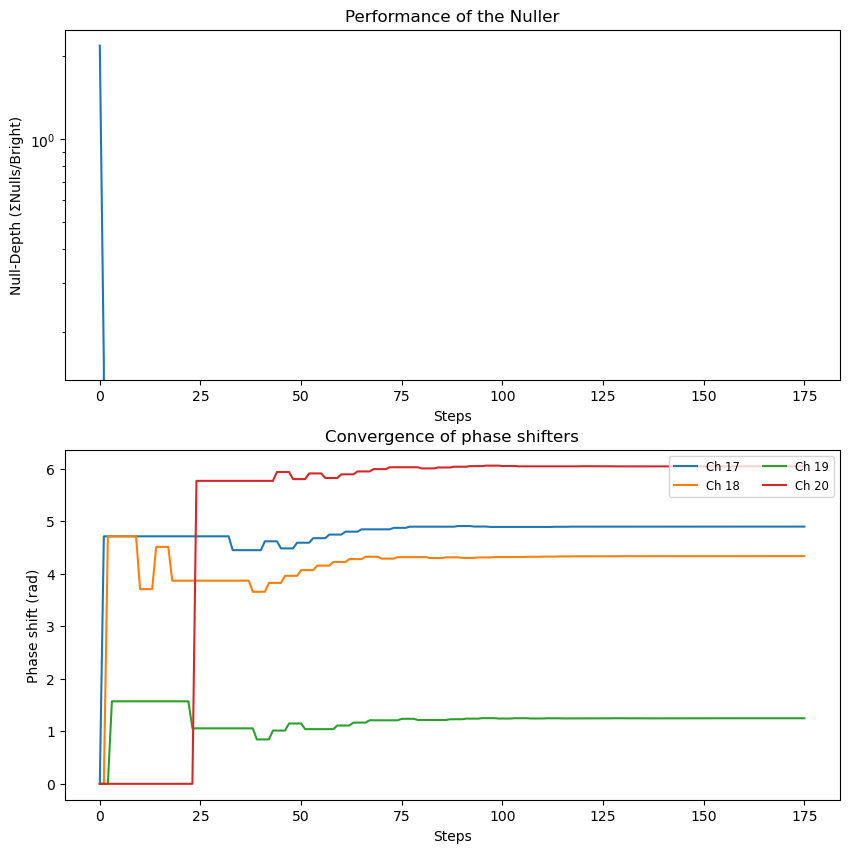

In [9]:
calibration_results = phobos.Arch6().null_calibration_gen(plot=True)


In [10]:
calibration_results

{'depth': array([ 2.18527348,  0.15323486, -0.40656711, -0.58621766, -0.59748775,
        -0.58632611, -0.59799757, -0.58308459, -0.59527984, -0.59552396,
        -0.59440608, -0.59154581, -0.60438131, -0.58874286, -0.59159422,
        -0.60585197, -0.59782179, -0.59746277, -0.59911654, -0.60454795,
        -0.59920939, -0.60062412, -0.59494145, -0.59816052, -0.59771584,
        -0.61117467, -0.60605411, -0.6097397 , -0.60450694, -0.60842947,
        -0.60515579, -0.60220694, -0.60984934, -0.60885751, -0.60715884,
        -0.60700674, -0.60689724, -0.60468216, -0.60142148, -0.60922394,
        -0.59808949, -0.59441013, -0.60199403, -0.60730452, -0.59819086,
        -0.60139607, -0.59702492, -0.59440924, -0.60780652, -0.60592654,
        -0.60137863, -0.60415936, -0.59654906, -0.60286834, -0.61464951,
        -0.59825652, -0.60389299, -0.60493191, -0.60270782, -0.59810365,
        -0.60149017, -0.59417411, -0.58769459, -0.60011274, -0.59633089,
        -0.59863648, -0.60169087, -0.59461

In [ ]:
# px window around the output
crop_size = 11

crop_centers = np.array([(285, 210),
                        (317, 210),
                        (350, 210),
                        (382, 210)])

# Power ramp
ramp = np.linspace(0, 1.2, 101) # [W]

# Controlled equipments
cam = kbench.Cred3()
try:
    dm = kbench.DM()
except ValueError:
    pass

In [ ]:
segOn = load_tt('/media/photonics/SSD 128Go/data/2025-12-19/001/TT_config.json', 'segOn')
segOff = load_tt('/media/photonics/SSD 128Go/data/2025-12-19/001/TT_config.json', 'segOff')
# [dm.segments[int(segOff[i, 0])].set_ptt(segOff[i, 1], segOff[i, 2], segOff[i, 3]) for i in range(segOff[:, 0].size)]
[dm.segments[int(segOn[i, 0])].set_ptt(segOn[i, 1], segOn[i, 2], segOn[i, 3]) for i in range(segOn[:, 0].size)]

# selected_beams = 1
# dm.segments[int(segOn[selected_beams, 0])].set_ptt(segOn[selected_beams, 1], segOn[selected_beams, 2], segOn[selected_beams, 3])

---

# Shifter calibration

In [ ]:
# shifter = arch.channels[3]
# shifter.dac_calibration(plot=False)
[elt.dac_calibration(plot=False) for elt in arch.channels]

---

# Calibrate phase

In [ ]:
out_fluxes = arch.phase_calibration(samples=100, cred3_object=cam, crop_centers=crop_centers, crop_sizes=crop_size, plot=True, verbose=False)

---

# Null calibration

In [ ]:
_ = arch.null_calibration_gen(cred3_object=cam, crop_centers=crop_centers, crop_sizes=crop_size, plot=True)

---

# Scan on one shifter using 1 & 2 inputs

In [ ]:
kbench.xpow.turn_off()

In [ ]:
arch.characterize(dm_object=dm, cred3_object=cam, crop_centers=crop_centers, crop_sizes=10, phase_samples=51, n_averages=10, plot=True, verbose=False)

---

In [ ]:
# # Test the new set_power() method with auto-calibration
# shifter = kbench.PhaseShifter(17)

# power_range = np.linspace(0, 1, 31)

# real_voltage = np.empty_like(power_range)
# real_current = np.empty_like(power_range)
# real_power = np.empty_like(power_range)

# for i, p in enumerate(power_range):
#     shifter.set_power(p)
#     real_voltage[i] = shifter.get_voltage()
#     real_current[i] = shifter.get_current()
#     real_power[i] = shifter.get_power()

# print(real_current, real_voltage, real_power)

# fig, axs = plt.subplots(1, 3, figsize=(12, 4))
# axs[0].plot(power_range, real_voltage, '-o')
# axs[0].set_ylabel("Voltage (V)")
# axs[0].set_xlabel("Set Power (W)")
# axs[0].grid()

# axs[1].plot(power_range, real_current, '-o')
# axs[1].set_ylabel("Current (mA)")
# axs[1].set_xlabel("Set Power (W)")
# axs[1].grid()

# axs[2].plot(power_range, real_power, '-o')
# axs[2].plot(power_range, power_range, '--', label='Ideal')
# axs[2].set_ylabel("Measured Power (W)")
# axs[2].set_xlabel("Set Power (W)")
# axs[2].legend()
# axs[2].grid()
# plt.tight_layout()


In [ ]:
# # Data acquisition
# flux = []
# for power in ramp:
#     shifter.set_power(power)
#     flux.append(cam.get_outputs(crop_centers=crop_centers, crop_sizes=crop_size))


# plt.figure()
# plt.plot(ramp, flux)
# plt.xlabel("Power (W)")
# plt.ylabel("Flux (ADU)")
# plt.title("Flux vs Power")
# plt.grid()

# sleep(3)
# shifter.turn_off()

In [ ]:
arch.phase_calibration(samples=50, cred3_object=cam, crop_centers=crop_centers, crop_sizes=crop_size, plot=True)

In [ ]:
# dm.segments[135].set_ptt(-1150, 0, -5.47)
# dm.segments[136].set_ptt(-1150, 0, -5.47)
# dm.segments[137].set_ptt(-1150, 0, -5.47)
# dm.segments[138].set_ptt(-1150, 0, -5.47)
# dm.segments[135].set_ptt(-1150,0,0)
# dm.segments[136].set_ptt(-1150,0,0)
# dm.segments[137].set_ptt(-1150,0,0)
# dm.segments[138].set_ptt(-1150,0,0)



In [ ]:
# Power ramp
ramp = np.linspace(0, 2*np.pi, 101) # [W]

# Data acquisition
flux = []
for shift in ramp:
    shifter.set_phase(shift)
    temp = []
    for i in range(20):
        temp.append(cam.get_outputs(crop_centers=crop_centers, crop_sizes=crop_size))
    flux.append(np.mean(temp, 0))
flux = np.array(flux)
kbench.xpow.turn_off()

In [ ]:
# Power ramp
ramp = np.linspace(0, 2*np.pi, 101) # [W]

# Data acquisition
flux2 = []
for shift in ramp:
    shifter.set_phase(shift*0)
    temp = []
    for i in range(20):
        temp.append(cam.get_outputs(crop_centers=crop_centers, crop_sizes=crop_size))
    flux2.append(np.mean(temp, 0))
flux2 = np.array(flux2)
kbench.xpow.turn_off()

In [ ]:
# plt.figure()
# plt.plot(ramp, flux, label='With phase shift')
# # plt.plot(ramp, flux2, '--', label='Without phase shift')
# plt.xlabel("Phase (rad)")
# plt.ylabel("Flux (ADU)")
# plt.title("Flux vs Phase")
# plt.grid()
# plt.tight_layout()
# plt.savefig("/media/photonics/SSD 128Go/data/2025-12-04/001/phase_vs_flux.png", dpi=150)

In [ ]:
plt.figure()
plt.plot(ramp, flux-flux.mean(0), label='With phase shift')
plt.plot(ramp, np.sum(flux-flux.mean(0), axis=1), ':', label='With')
plt.plot(ramp, flux2-flux2.mean(0), '--', label='Without phase shift')
plt.xlabel("Phase (rad)")
plt.ylabel("Flux (ADU)")
plt.title("Flux vs Phase")
plt.grid()
plt.tight_layout()
# plt.savefig("/media/photonics/SSD 128Go/data/2025-12-04/001/phase_vs_flux_avg0.png", dpi=150)

In [ ]:
# frame = cam.get_image()
# np.save("/media/photonics/SSD 128Go/data/2025-12-04/001/frame_ttoff.npy", frame)